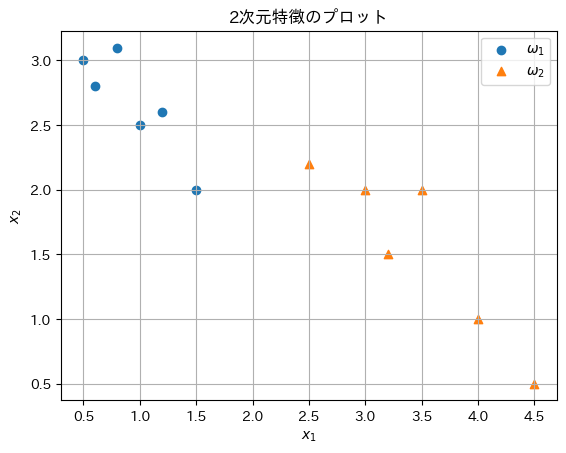

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
from io import StringIO

import matplotlib.font_manager as fm
# Data provided
data_str = """\
class x1 x2
1 0.5 3.0
1 1.0 2.5
1 0.8 3.1
1 1.2 2.6
1 1.5 2.0
1 0.6 2.8
0 3.0 2.0
0 4.0 1.0
0 3.5 2.0
0 4.5 0.5
0 2.5 2.2
0 3.2 1.5
"""
font_path = "ipaexg.ttf"  # Adjust this to your IPAexGothic path
fm.fontManager.addfont(font_path)
ipa_font = fm.FontProperties(fname=font_path)
plt.rcParams["font.family"] = ipa_font.get_name()

# Read into DataFrame
df = pd.read_csv(StringIO(data_str), sep=r'\s+')

# Separate classes
df_class1 = df[df['class'] == 1]
df_class0 = df[df['class'] == 0]

# Plot
plt.figure()
plt.scatter(df_class1['x1'], df_class1['x2'], marker='o', label=r'$\omega_1$')
plt.scatter(df_class0['x1'], df_class0['x2'], marker='^', label=r'$\omega_2$')
plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.title('2次元特徴のプロット')
plt.legend()
plt.grid(True)
plt.show()


Usage: python plot-boundary.py data_file slope1 intercept1 slope2 intercept2 slope3 intercept3 output.png


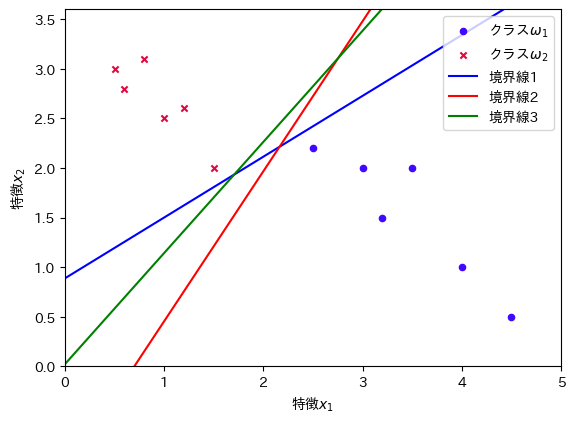

: 

In [ ]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

if len(sys.argv) != 6:
    print('Usage: python plot-boundary.py data_file slope1 intercept1 slope2 intercept2 slope3 intercept3 output.png', file=sys.stderr)
    exit()

data_file = "mydata.dat"
slope1 = 0.613
intercept1 = 0.887
slope2 = 1.512
intercept2 = -1.058
slope3 = 1.120
intercept3 = 0.022
png_file = "boundary.png"

x = np.loadtxt(data_file, usecols=[1, 2])
y = np.loadtxt(data_file, usecols=[0], dtype=int)

# Set font (example IPAexG)
font_path = "ipaexg.ttf"
fm.fontManager.addfont(font_path)
ipa_font = fm.FontProperties(fname=font_path)
plt.rcParams["font.family"] = ipa_font.get_name()

plt.axes().set_aspect('equal')
c1 = (64/255, 8/255, 255/255)
c2 = (224/255, 8/255, 64/255)

margin = 0.5
x_min, x_max = x[:, 0].min() - margin, x[:, 0].max() + margin
y_min, y_max = x[:, 1].min() - margin, x[:, 1].max() + margin

x1_points = x[y == 0]
x2_points = x[y == 1]

plt.scatter(x1_points[:, 0], x1_points[:, 1], color=c1, marker='o', s=20, label=r'クラス$\omega_1$')
plt.scatter(x2_points[:, 0], x2_points[:, 1], color=c2, marker='x', s=20, label=r'クラス$\omega_2$')

linex = np.linspace(x_min, x_max, 500)

# Plot all three decision boundaries
plt.plot(linex, slope1 * linex + intercept1, label='境界線1', color='blue')
plt.plot(linex, slope2 * linex + intercept2, label='境界線2', color='red')
plt.plot(linex, slope3 * linex + intercept3, label='境界線3', color='green')

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.xlabel(r'特徴$x_1$')
plt.ylabel(r'特徴$x_2$')

plt.legend(loc='upper right')
plt.savefig(png_file, dpi=400)
